In [59]:
import pandas as pd
import numpy as np
import sklearn
import seaborn as sns
import matplotlib.pyplot as plt

#pd.set_option('display.max_rows', None) #строк много, поэтоу воспользуемся этой опцией

In [60]:
df_train = pd.read_csv("train.csv")
df_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.00,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.00,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.00,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.00,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.00,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [61]:
X_test_final = pd.read_csv("test.csv")
X_test_final.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.00,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.00,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.00,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.00,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.00,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [62]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [63]:
df_train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.00,1460.00,1201.00,1460.00,1460.00,1460.00,1460.00,1460.00,1452.00,1460.00,...,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00
mean,730.50,56.90,70.05,10516.83,6.10,5.58,1971.27,1984.87,103.69,443.64,...,94.24,46.66,21.95,3.41,15.06,2.76,43.49,6.32,2007.82,180921.20
std,421.61,42.30,24.28,9981.26,1.38,1.11,30.20,20.65,181.07,456.10,...,125.34,66.26,61.12,29.32,55.76,40.18,496.12,2.70,1.33,79442.50
min,1.00,20.00,21.00,1300.00,1.00,1.00,1872.00,1950.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,2006.00,34900.00
25%,365.75,20.00,59.00,7553.50,5.00,5.00,1954.00,1967.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,5.00,2007.00,129975.00
50%,730.50,50.00,69.00,9478.50,6.00,5.00,1973.00,1994.00,0.00,383.50,...,0.00,25.00,0.00,0.00,0.00,0.00,0.00,6.00,2008.00,163000.00
75%,1095.25,70.00,80.00,11601.50,7.00,6.00,2000.00,2004.00,166.00,712.25,...,168.00,68.00,0.00,0.00,0.00,0.00,0.00,8.00,2009.00,214000.00
max,1460.00,190.00,313.00,215245.00,10.00,9.00,2010.00,2010.00,1600.00,5644.00,...,857.00,547.00,552.00,508.00,480.00,738.00,15500.00,12.00,2010.00,755000.00


In [64]:
df_train.columns
#Оставим столбцы, полезные для модели по смыслу
#Для этого выберем признаки на основе корреляции и также те, у которых нет мультиколлинераности между собой


Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

<Axes: >

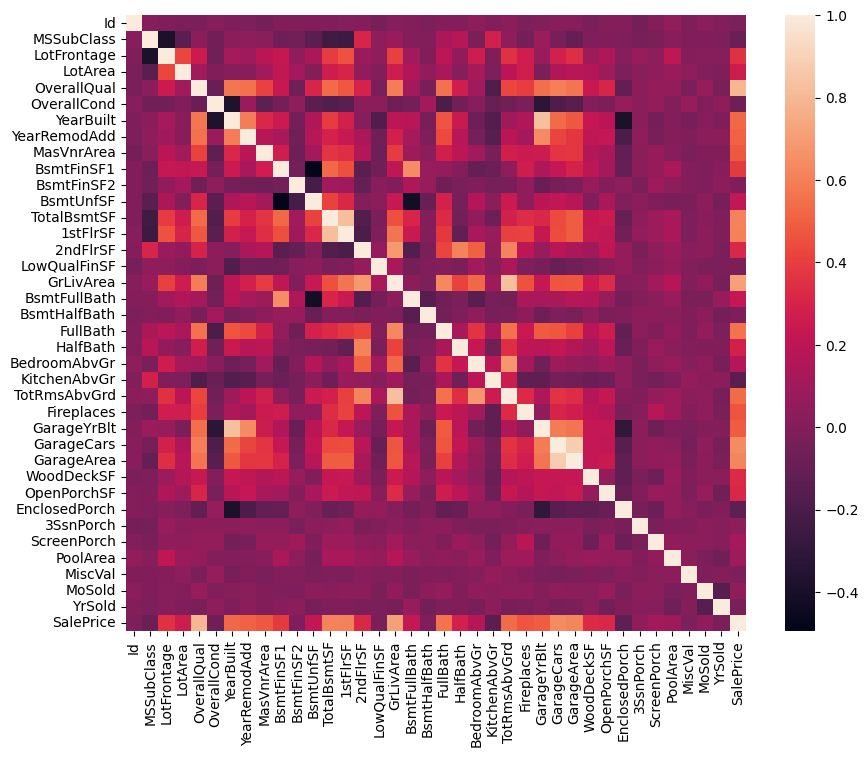

In [65]:
plt.figure(figsize=(10,8))
sns.heatmap(df_train.select_dtypes(include='number').corr())

In [66]:
selected_features = df_train.corr(numeric_only=True)['SalePrice'][lambda x: x.abs() > 0.5].index.tolist()
selected_features

['OverallQual',
 'YearBuilt',
 'YearRemodAdd',
 'TotalBsmtSF',
 '1stFlrSF',
 'GrLivArea',
 'FullBath',
 'TotRmsAbvGrd',
 'GarageCars',
 'GarageArea',
 'SalePrice']

In [67]:
df_train[['OverallQual',
 'YearBuilt',
 'YearRemodAdd',
 'TotalBsmtSF',
 '1stFlrSF',
 'GrLivArea',
 'FullBath',
 'TotRmsAbvGrd',
 'GarageCars',
 'GarageArea',
 'SalePrice']].corr()

,OverallQual,YearBuilt,YearRemodAdd,TotalBsmtSF,1stFlrSF,GrLivArea,FullBath,TotRmsAbvGrd,GarageCars,GarageArea,SalePrice
OverallQual,1.00,0.57,0.55,0.54,0.48,0.59,0.55,0.43,0.60,0.56,0.79
YearBuilt,0.57,1.00,0.59,0.39,0.28,0.20,0.47,0.10,0.54,0.48,0.52
YearRemodAdd,0.55,0.59,1.00,0.29,0.24,0.29,0.44,0.19,0.42,0.37,0.51
TotalBsmtSF,0.54,0.39,0.29,1.00,0.82,0.45,0.32,0.29,0.43,0.49,0.61
1stFlrSF,0.48,0.28,0.24,0.82,1.00,0.57,0.38,0.41,0.44,0.49,0.61
GrLivArea,0.59,0.20,0.29,0.45,0.57,1.00,0.63,0.83,0.47,0.47,0.71
FullBath,0.55,0.47,0.44,0.32,0.38,0.63,1.00,0.55,0.47,0.41,0.56
TotRmsAbvGrd,0.43,0.10,0.19,0.29,0.41,0.83,0.55,1.00,0.36,0.34,0.53
GarageCars,0.60,0.54,0.42,0.43,0.44,0.47,0.47,0.36,1.00,0.88,0.64
GarageArea,0.56,0.48,0.37,0.49,0.49,0.47,0.41,0.34,0.88,1.00,0.62


 Эти показатели связаны друг с другом по смылу, корреляция у них 0,88:
 'GarageCars',
 'GarageArea'
 Оставлять оба эти показателя избыточно
 Оставим только GarageCars, поскольку у него корреляция с таргетом выше и составляет 0 ,64, против 0,62 у GarageArea

 У остальных факторов между собой меньше 0,8 корреляция, поэтому оставим их

Итоговой список числовых показателей для моделей:
'OverallQual',
 'YearBuilt',
 'YearRemodAdd',
 'TotalBsmtSF',
 '1stFlrSF',
 'GrLivArea',
 'FullBath',
 'TotRmsAbvGrd',
 'GarageCars',
 'SalePrice'

Теперь отберем категориалньые факторы

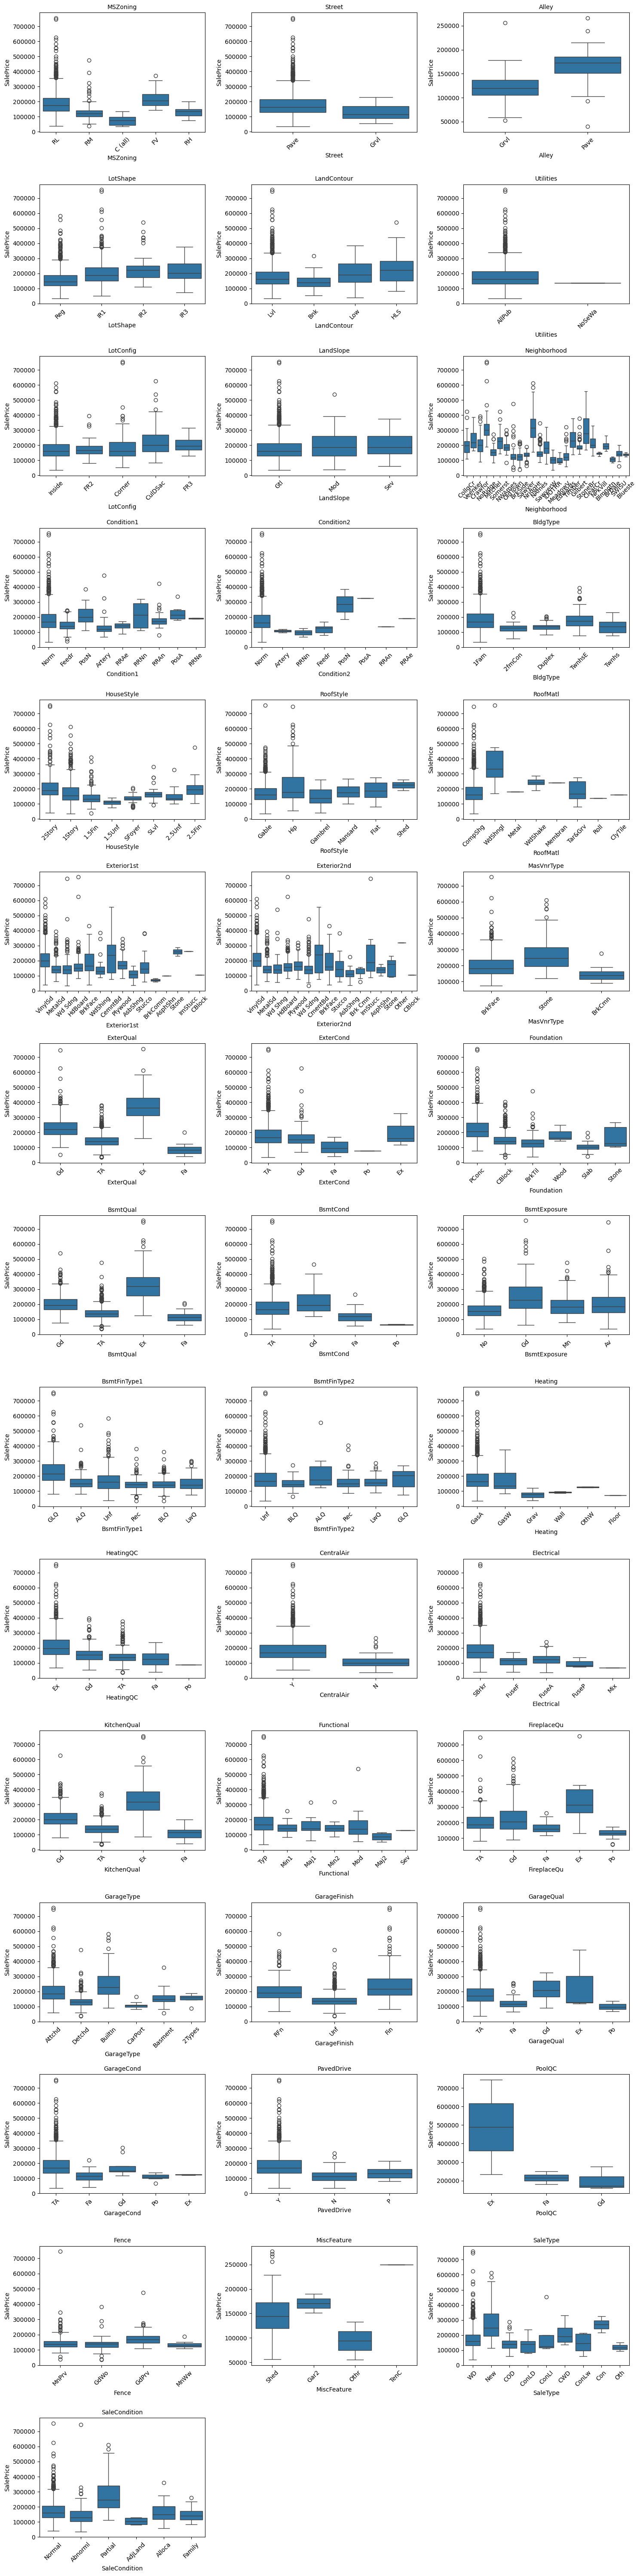

In [68]:
li_cat_feats = list(df_train.select_dtypes(include=['object', 'category']).columns)

nr_rows = 15
nr_cols = 3

fig, axs = plt.subplots(nr_rows, nr_cols, figsize=(nr_cols*5, nr_rows*4))

for r in range(0, nr_rows):
    for c in range(0, nr_cols):  
        i = r * nr_cols + c
        if i < len(li_cat_feats):
            try:
                sns.boxplot(
                    x=li_cat_feats[i], 
                    y=df_train['SalePrice'], 
                    data=df_train, 
                    ax=axs[r][c]
                )
                axs[r][c].tick_params(axis='x', rotation=45)
                axs[r][c].set_title(li_cat_feats[i], fontsize=10)
            except Exception as e:
                axs[r][c].text(0.5, 0.5, f'Ошибка: {li_cat_feats[i]}\n{str(e)}', 
                               ha='center', va='center')
                axs[r][c].set_title(li_cat_feats[i])
        else:
            axs[r][c].axis('off')

plt.tight_layout()    
plt.show()

In [69]:
categorical_features = df_train.select_dtypes(include=['object', 'category']).columns.tolist()
len(categorical_features)

43

Для дальнейшего построения моделей оставим только эти категориальные признаки
'MSZoning', 'Neighborhood', 'Condition2', 'MasVnrType', 'ExterQual', 'BsmtQual','CentralAir', 'Electrical', 'KitchenQual', 'SaleType'
поскольку у них наиболее четкая и сильная корреляция
Остальнвые категориальные признаки вносят шум в данные

In [70]:
y_train = pd.DataFrame(df_train['SalePrice'])
X_train = df_train[['OverallQual',
 'YearBuilt',
 'YearRemodAdd',
 'TotalBsmtSF',
 '1stFlrSF',
 'GrLivArea',
 'FullBath',
 'TotRmsAbvGrd',
 'GarageCars',
 'MSZoning', 
 'Neighborhood', 
 'Condition2', 
 'MasVnrType', 
 'ExterQual', 
 'BsmtQual',
 'CentralAir', 
 'Electrical', 
 'KitchenQual', 
 'SaleType']]

In [71]:
X_test_final = X_test_final[['OverallQual',
 'YearBuilt',
 'YearRemodAdd',
 'TotalBsmtSF',
 '1stFlrSF',
 'GrLivArea',
 'FullBath',
 'TotRmsAbvGrd',
 'GarageCars',
 'MSZoning', 
 'Neighborhood', 
 'Condition2', 
 'MasVnrType', 
 'ExterQual', 
 'BsmtQual',
 'CentralAir', 
 'Electrical', 
 'KitchenQual', 
 'SaleType']]

In [72]:
for col in X_train:
    if X_train[col].dtype in ['int64', 'float64']:
        X_train[col].fillna(X_train[col].median(), inplace=True)
    else:
        X_train[col].fillna(X_train[col].mode()[0], inplace=True)

for col in X_test_final:
    if X_test_final[col].dtype in ['int64', 'float64']:
        X_test_final[col].fillna(X_test_final[col].median(), inplace=True)
    else:
        X_test_final[col].fillna(X_test_final[col].mode()[0], inplace=True)

C:\Users\kate1\AppData\Local\Temp\ipykernel_2820\1621663038.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train[col].fillna(X_train[col].median(), inplace=True)
C:\Users\kate1\AppData\Local\Temp\ipykernel_2820\1621663038.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[col].fillna(X_train[col].median(), inplace=True)
C:\User

In [73]:
X_train.isna().sum()[X_train.isna().sum() > 0]

Series([], dtype: int64)

In [74]:
X_test_final.isna().sum()[X_test_final.isna().sum() > 0]

Series([], dtype: int64)

In [75]:
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer

num_col = X_train.select_dtypes(include=['int64', 'float64']).columns
other_col = X_train.select_dtypes(exclude=['int64', 'float64']).columns

feature_names = (list(num_col) + list(other_col))

transform = ColumnTransformer(
    transformers=[('num', RobustScaler(), num_col)],
    remainder='passthrough'
)

scaler = RobustScaler()

train_df_scal = transform.fit_transform(X_train)
test_df_scal = transform.transform(X_test_final)

X_train = pd.DataFrame(train_df_scal, columns=feature_names)
X_test_final = pd.DataFrame(test_df_scal, columns=feature_names)

In [76]:
X_train[['OverallQual',
 'YearBuilt',
 'YearRemodAdd',
 'TotalBsmtSF',
 '1stFlrSF',
 'GrLivArea',
 'FullBath',
 'TotRmsAbvGrd',
 'GarageCars']] = X_train[['OverallQual',
 'YearBuilt',
 'YearRemodAdd',
 'TotalBsmtSF',
 '1stFlrSF',
 'GrLivArea',
 'FullBath',
 'TotRmsAbvGrd',
 'GarageCars']].astype(int)

In [ ]:
X_test_final[['OverallQual',
 'YearBuilt',
 'YearRemodAdd',
 'TotalBsmtSF',
 '1stFlrSF',
 'GrLivArea',
 'FullBath',
 'TotRmsAbvGrd',
 'GarageCars']] = X_test_final[['OverallQual',
 'YearBuilt',
 'YearRemodAdd',
 'TotalBsmtSF',
 '1stFlrSF',
 'GrLivArea',
 'FullBath',
 'TotRmsAbvGrd',
 'GarageCars']].astype(int)

In [78]:
X_train.nunique()

OverallQual      5
YearBuilt        3
YearRemodAdd     2
TotalBsmtSF      7
1stFlrSF         7
GrLivArea        7
FullBath         4
TotRmsAbvGrd     7
GarageCars       5
MSZoning         5
Neighborhood    25
Condition2       8
MasVnrType       3
ExterQual        4
BsmtQual         4
CentralAir       2
Electrical       5
KitchenQual      4
SaleType         9
dtype: int64

In [79]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   OverallQual   1460 non-null   int64 
 1   YearBuilt     1460 non-null   int64 
 2   YearRemodAdd  1460 non-null   int64 
 3   TotalBsmtSF   1460 non-null   int64 
 4   1stFlrSF      1460 non-null   int64 
 5   GrLivArea     1460 non-null   int64 
 6   FullBath      1460 non-null   int64 
 7   TotRmsAbvGrd  1460 non-null   int64 
 8   GarageCars    1460 non-null   int64 
 9   MSZoning      1460 non-null   object
 10  Neighborhood  1460 non-null   object
 11  Condition2    1460 non-null   object
 12  MasVnrType    1460 non-null   object
 13  ExterQual     1460 non-null   object
 14  BsmtQual      1460 non-null   object
 15  CentralAir    1460 non-null   object
 16  Electrical    1460 non-null   object
 17  KitchenQual   1460 non-null   object
 18  SaleType      1460 non-null   object
dtypes: int

Обработаем категориальные переменные

In [80]:
#Для порядковых категориальных данных воспользуемся лейбл енкодингом
order = {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}

X_train['ExterQual'] = X_train['ExterQual'].map(order)
X_train['KitchenQual'] = X_train['KitchenQual'].map(order)
X_train['BsmtQual'] = X_train['BsmtQual'].map(order)
X_train['CentralAir'] = X_train['CentralAir'].map({'Y': 1, 'N': 0})

X_test_final['ExterQual'] = X_test_final['ExterQual'].map(order)
X_test_final['KitchenQual'] = X_test_final['KitchenQual'].map(order)
X_test_final['BsmtQual'] = X_test_final['BsmtQual'].map(order)
X_test_final['CentralAir'] = X_test_final['CentralAir'].map({'Y': 1, 'N': 0})

In [81]:
#Для обычных категориальных переменных без порядка с небольшим количеством уникальных значений воспользуемся
#просто one-hot енкодингом
X_train = pd.get_dummies(X_train, columns=['MSZoning', 'Condition2', 'MasVnrType', 'Electrical', 'SaleType'], drop_first=True)
X_test_final = pd.get_dummies(X_test_final, columns=['MSZoning', 'Condition2', 'MasVnrType', 'Electrical', 'SaleType'], drop_first=True)

In [82]:
#У этого столбца Neighborhood 25 уникальных значений, это достаточно много, поэтому воспользуемся таргет енкодингом
from category_encoders import TargetEncoder
TE = TargetEncoder(cols=['Neighborhood'])
X_train['Neighborhood_enc'] = TE.fit_transform(X_train['Neighborhood'], y_train['SalePrice'])
X_test_final['Neighborhood_enc'] = TE.transform(X_test_final['Neighborhood'])
X_train = X_train.drop('Neighborhood', axis=1)
X_test_final = X_test_final.drop('Neighborhood', axis=1)


In [83]:
#Готовим данные
from sklearn.model_selection import train_test_split, cross_val_score

X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.2, random_state=42)


In [84]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [85]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.model_selection import RandomizedSearchCV

In [86]:
def get_model_scores(model, X_train, y_train, X_test, y_test):
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    rmse_train = round(np.sqrt(mean_squared_error(y_train, y_pred_train)), 4)
    rmse_test = round(np.sqrt(mean_squared_error(y_test, y_pred_test)), 4)
    mae = round(mean_absolute_error(y_test, y_pred_test), 4)
    mse = round(mean_squared_error(y_test, y_pred_test), 4)
    r2 = round(r2_score(y_test, y_pred_test), 4)
    rmse_cv = round(np.sqrt(-cross_val_score(model, X_train, y_train, scoring="neg_mean_squared_error", cv=5)).mean(), 4)
    return rmse_test, rmse_train, mae, mse, r2, rmse_cv

In [87]:
def add_result(results_df, model_name, RMSE_test, RMSE_train, MAE, MSE, R2, cross_val):
    new_row = pd.DataFrame([[model_name, RMSE_test, RMSE_train, MAE, MSE, R2, cross_val]], 
              columns=["Model","RMSE_test", "RMSE_train", "MAE","MSE","R2", "Cross-Val"])
    results_df = pd.concat([results_df, new_row], ignore_index=True)
    return results_df

results = pd.DataFrame(columns=["Model","RMSE_test", "RMSE_train", "MAE","MSE","R2", "Cross-Val"])

In [88]:
lin = LinearRegression()
lin.fit(X_train, y_train)

rmse_test, rmse_train, mae, mse, r2, rmse_cv = get_model_scores(lin, X_train, y_train, X_test, y_test)

print(f'RMSE_test: {rmse_test}, RMSE_train: {rmse_train}, MAE: {mae}, MSE: {mse}, r2: {r2}, RMSE_CV: {rmse_cv}')

results = add_result(results, lin, rmse_test, rmse_train, mae, mse, r2, rmse_cv)
results

RMSE_test: 37323.2549, RMSE_train: 35182.187, MAE: 25102.2066, MSE: 1393025354.0488, r2: 0.8184, RMSE_CV: 39854.5875


C:\Users\kate1\AppData\Local\Temp\ipykernel_2820\3526237718.py:4: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, new_row], ignore_index=True)


,Model,RMSE_test,RMSE_train,MAE,MSE,R2,Cross-Val
0,LinearRegression(),37323.25,35182.19,25102.21,1393025354.05,0.82,39854.59


In [89]:
pd.set_option('display.float_format', '{:.2f}'.format)

In [90]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

best_rmse_cv = 0
best_params = None
best_model_obj = None
best_scores = {}

for alpha in alphas:
    ridge = Ridge(alpha=alpha, random_state=42)
    ridge.fit(X_train, y_train)
    y_pred = ridge.predict(X_test)
    
    rmse_test, rmse_train, mae, mse, r2, rmse_cv = get_model_scores(ridge, X_train, y_train, X_test, y_test)
    
    print(f'RMSE_test: {rmse_test}, RMSE_train: {rmse_train}, MAE: {mae}, MSE: {mse}, r2: {r2}, RMSE_CV: {rmse_cv}')

    if rmse_test > best_rmse_cv and (rmse_train - rmse_test) <=0.1:
        best_rmse_cv = rmse_cv
        best_alpha = alpha
        best_model = ridge
        best_scores = {
            'rmse_test': rmse_test,
            'rmse_train': rmse_train,
            'mae': mae,
            'mse': mse,
            'r2': r2,
            'rmse_cv': rmse_cv,
        }
    
results = add_result(results, best_model, best_scores['rmse_test'], best_scores['rmse_train'], best_scores['mae'], best_scores['mse'],
best_scores['r2'], best_scores['rmse_cv'])
results

RMSE_test: 37323.1787, RMSE_train: 35182.1873, MAE: 25102.1221, MSE: 1393019665.4486, r2: 0.8184, RMSE_CV: 39851.3885
RMSE_test: 37322.509, RMSE_train: 35182.2154, MAE: 25101.3635, MSE: 1392969676.6992, r2: 0.8184, RMSE_CV: 39823.477
RMSE_test: 37317.1102, RMSE_train: 35184.5299, MAE: 25093.8458, MSE: 1392566710.8261, r2: 0.8184, RMSE_CV: 39601.1339
RMSE_test: 37303.693, RMSE_train: 35270.8572, MAE: 25022.8735, MSE: 1391565509.138, r2: 0.8186, RMSE_CV: 38792.5776
RMSE_test: 37311.6779, RMSE_train: 35688.7007, MAE: 24861.9111, MSE: 1392161304.7911, r2: 0.8185, RMSE_CV: 38105.4523
RMSE_test: 38002.5472, RMSE_train: 36291.7769, MAE: 24820.9828, MSE: 1444193593.3833, r2: 0.8117, RMSE_CV: 37596.0081
RMSE_test: 44449.7058, RMSE_train: 41278.199, MAE: 28396.742, MSE: 1975776345.184, r2: 0.7424, RMSE_CV: 42444.4811


,Model,RMSE_test,RMSE_train,MAE,MSE,R2,Cross-Val
0,LinearRegression(),37323.25,35182.19,25102.21,1393025354.05,0.82,39854.59
1,"Ridge(alpha=1000, random_state=42)",44449.71,41278.20,28396.74,1975776345.18,0.74,42444.48


In [91]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

best_rmse_cv = 0
best_params = None
best_model_obj = None
best_scores = {}

for alpha in alphas:
    lasso = Lasso(alpha=alpha, random_state=42)
    lasso.fit(X_train, y_train)
    y_pred = lasso.predict(X_test)
    
    rmse_test, rmse_train, mae, mse, r2, rmse_cv = get_model_scores(lasso, X_train, y_train, X_test, y_test)
    
    print(f'RMSE_test: {rmse_test}, RMSE_train: {rmse_train}, MAE: {mae}, MSE: {mse}, r2: {r2}, RMSE_CV: {rmse_cv}')

    if rmse_test > best_rmse_cv and (rmse_train - rmse_test) <=0.1:
        best_rmse_cv = rmse_cv
        best_alpha = alpha
        best_model = lasso
        best_scores = {
            'rmse_test': rmse_test,
            'rmse_train': rmse_train,
            'mae': mae,
            'mse': mse,
            'r2': r2,
            'rmse_cv': rmse_cv,
        }
    
results = add_result(results, best_model, best_scores['rmse_test'], best_scores['rmse_train'], best_scores['mae'], best_scores['mse'],
best_scores['r2'], best_scores['rmse_cv'])
results

c:\Users\kate1\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.182e+10, tolerance: 5.256e+08
  model = cd_fast.enet_coordinate_descent(


RMSE_test: 37323.2409, RMSE_train: 35182.187, MAE: 25102.199, MSE: 1393024311.5843, r2: 0.8184, RMSE_CV: 39854.5621


c:\Users\kate1\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.109e+09, tolerance: 5.256e+08
  model = cd_fast.enet_coordinate_descent(


RMSE_test: 37323.1153, RMSE_train: 35182.187, MAE: 25102.1313, MSE: 1393014933.2121, r2: 0.8184, RMSE_CV: 39854.3409
RMSE_test: 37321.8638, RMSE_train: 35182.1893, MAE: 25101.4538, MSE: 1392921514.5425, r2: 0.8184, RMSE_CV: 39852.1302
RMSE_test: 37309.818, RMSE_train: 35182.4141, MAE: 25094.68, MSE: 1392022520.7536, r2: 0.8185, RMSE_CV: 39830.4769
RMSE_test: 37265.1145, RMSE_train: 35198.9315, MAE: 25051.9123, MSE: 1388688758.8375, r2: 0.819, RMSE_CV: 39646.4229
RMSE_test: 37064.1917, RMSE_train: 35620.9864, MAE: 24777.6505, MSE: 1373754306.7507, r2: 0.8209, RMSE_CV: 38849.0829
RMSE_test: 38092.6553, RMSE_train: 36360.9895, MAE: 25230.5335, MSE: 1451050387.2906, r2: 0.8108, RMSE_CV: 38032.2371


,Model,RMSE_test,RMSE_train,MAE,MSE,R2,Cross-Val
0,LinearRegression(),37323.25,35182.19,25102.21,1393025354.05,0.82,39854.59
1,"Ridge(alpha=1000, random_state=42)",44449.71,41278.20,28396.74,1975776345.18,0.74,42444.48
2,"Lasso(alpha=0.001, random_state=42)",37323.24,35182.19,25102.20,1393024311.58,0.82,39854.56


In [92]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0]

best_rmse_cv = 0
best_params = None
best_model_obj = None
best_scores = {}

for alpha in alphas:
    for rat in l1_ratios:
        elnet = ElasticNet(alpha=alpha, l1_ratio=rat, random_state=42)
        elnet.fit(X_train, y_train)
        y_pred = elnet.predict(X_test)
        
        rmse_test, rmse_train, mae, mse, r2, rmse_cv = get_model_scores(elnet, X_train, y_train, X_test, y_test)
        
        print(f'alpha = {alpha}, l1_ratio = {rat}')
        print(f'RMSE_test: {rmse_test}, RMSE_train: {rmse_train}, MAE: {mae}, MSE: {mse}, r2: {r2}, RMSE_CV: {rmse_cv}')
        
        if rmse_test > best_rmse_cv and (rmse_train - rmse_test) <=0.1:
            best_rmse_cv = rmse_cv
            best_alpha = alpha
            best_model = elnet
            best_scores = {
                'rmse_test': rmse_test,
                'rmse_train': rmse_train,
                'mae': mae,
                'mse': mse,
                'r2': r2,
                'rmse_cv': rmse_cv,
            }
    
results = add_result(results, best_model, best_scores['rmse_test'], best_scores['rmse_train'], best_scores['mae'], best_scores['mse'],
best_scores['r2'], best_scores['rmse_cv'])
results

alpha = 0.001, l1_ratio = 0.1
RMSE_test: 37303.56, RMSE_train: 35276.3945, MAE: 25019.9594, MSE: 1391555587.6867, r2: 0.8186, RMSE_CV: 38862.6177
alpha = 0.001, l1_ratio = 0.3
RMSE_test: 37304.3568, RMSE_train: 35250.9294, MAE: 25033.6782, MSE: 1391615032.9502, r2: 0.8186, RMSE_CV: 38967.4026
alpha = 0.001, l1_ratio = 0.5
RMSE_test: 37305.9255, RMSE_train: 35225.5842, MAE: 25052.7415, MSE: 1391732079.6808, r2: 0.8186, RMSE_CV: 39108.2435
alpha = 0.001, l1_ratio = 0.7
RMSE_test: 37309.1447, RMSE_train: 35202.274, MAE: 25072.5289, MSE: 1391972280.2066, r2: 0.8185, RMSE_CV: 39307.6641


c:\Users\kate1\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.165e+09, tolerance: 5.256e+08
  model = cd_fast.enet_coordinate_descent(
c:\Users\kate1\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.246e+10, tolerance: 5.256e+08
  model = cd_fast.enet_coordinate_descent(


alpha = 0.001, l1_ratio = 0.9
RMSE_test: 37316.2998, RMSE_train: 35185.2897, MAE: 25092.4325, MSE: 1392506233.7802, r2: 0.8185, RMSE_CV: 39614.7739
alpha = 0.001, l1_ratio = 0.95
RMSE_test: 37319.3339, RMSE_train: 35183.0542, MAE: 25097.3107, MSE: 1392732684.8179, r2: 0.8184, RMSE_CV: 39722.4782


c:\Users\kate1\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.182e+10, tolerance: 5.256e+08
  model = cd_fast.enet_coordinate_descent(


alpha = 0.001, l1_ratio = 1.0
RMSE_test: 37323.2409, RMSE_train: 35182.187, MAE: 25102.199, MSE: 1393024311.5843, r2: 0.8184, RMSE_CV: 39854.5621
alpha = 0.01, l1_ratio = 0.1
RMSE_test: 37313.1827, RMSE_train: 35698.2767, MAE: 24858.1604, MSE: 1392273604.159, r2: 0.8185, RMSE_CV: 38150.9411
alpha = 0.01, l1_ratio = 0.3
RMSE_test: 37307.1925, RMSE_train: 35649.3839, MAE: 24876.6533, MSE: 1391826611.4807, r2: 0.8185, RMSE_CV: 38215.7523
alpha = 0.01, l1_ratio = 0.5
RMSE_test: 37303.6712, RMSE_train: 35581.3273, MAE: 24899.6482, MSE: 1391563881.3466, r2: 0.8186, RMSE_CV: 38302.1957
alpha = 0.01, l1_ratio = 0.7
RMSE_test: 37302.6184, RMSE_train: 35475.913, MAE: 24930.361, MSE: 1391485335.8298, r2: 0.8186, RMSE_CV: 38440.289
alpha = 0.01, l1_ratio = 0.9
RMSE_test: 37303.3011, RMSE_train: 35288.9057, MAE: 25013.3897, MSE: 1391536273.6872, r2: 0.8186, RMSE_CV: 38819.5891
alpha = 0.01, l1_ratio = 0.95
RMSE_test: 37305.8955, RMSE_train: 35225.6101, MAE: 25052.7115, MSE: 1391729841.553, r2: 0.81

c:\Users\kate1\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.109e+09, tolerance: 5.256e+08
  model = cd_fast.enet_coordinate_descent(


alpha = 0.01, l1_ratio = 1.0
RMSE_test: 37323.1153, RMSE_train: 35182.187, MAE: 25102.1313, MSE: 1393014933.2121, r2: 0.8184, RMSE_CV: 39854.3409
alpha = 0.1, l1_ratio = 0.1
RMSE_test: 38048.5645, RMSE_train: 36320.1638, MAE: 24827.9488, MSE: 1447693263.1997, r2: 0.8113, RMSE_CV: 37592.2549
alpha = 0.1, l1_ratio = 0.3
RMSE_test: 37840.1852, RMSE_train: 36191.5002, MAE: 24799.8497, MSE: 1431879616.7725, r2: 0.8133, RMSE_CV: 37615.642
alpha = 0.1, l1_ratio = 0.5
RMSE_test: 37638.7747, RMSE_train: 36063.6756, MAE: 24779.6647, MSE: 1416677362.1534, r2: 0.8153, RMSE_CV: 37681.9871
alpha = 0.1, l1_ratio = 0.7
RMSE_test: 37453.9418, RMSE_train: 35928.732, MAE: 24781.2535, MSE: 1402797758.0957, r2: 0.8171, RMSE_CV: 37818.3159
alpha = 0.1, l1_ratio = 0.9
RMSE_test: 37316.8942, RMSE_train: 35718.4562, MAE: 24850.4507, MSE: 1392550589.9219, r2: 0.8184, RMSE_CV: 38123.2666
alpha = 0.1, l1_ratio = 0.95
RMSE_test: 37303.481, RMSE_train: 35581.593, MAE: 24899.5261, MSE: 1391549694.8902, r2: 0.8186, R

,Model,RMSE_test,RMSE_train,MAE,MSE,R2,Cross-Val
0,LinearRegression(),37323.25,35182.19,25102.21,1393025354.05,0.82,39854.59
1,"Ridge(alpha=1000, random_state=42)",44449.71,41278.20,28396.74,1975776345.18,0.74,42444.48
2,"Lasso(alpha=0.001, random_state=42)",37323.24,35182.19,25102.20,1393024311.58,0.82,39854.56
3,"ElasticNet(alpha=1000, l1_ratio=0.95, random_s...",56902.09,53421.94,37838.62,3237848231.35,0.58,53329.18


In [93]:
param_dist = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 20, 25],     
    'weights': ['uniform', 'distance'],                
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2],                                       
    'leaf_size': [20, 30, 40, 50],                    
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'] 
}

best_rmse_cv = 0
best_params = None
best_model = None
best_scores = {}

random_knn = RandomizedSearchCV(
    KNeighborsRegressor(),
    param_distributions=param_dist,
    n_iter=100,  
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_knn.fit(X_train, y_train)

best_knn = random_knn.best_estimator_
best_params = random_knn.best_params_

model_name = f"KNN_n={best_params['n_neighbors']}_w={best_params['weights']}_metric={best_params['metric']}_p={best_params.get('p', 2)}_leaf={best_params['leaf_size']}_alg={best_params['algorithm']}"

rmse_test, rmse_train, mae, mse, r2, rmse_cv = get_model_scores(
    best_knn, X_train, y_train, X_test, y_test
)

results = add_result(results, model_name, rmse_test, rmse_train, mae, mse, r2, rmse_cv)
results

Fitting 5 folds for each of 100 candidates, totalling 500 fits


c:\Users\kate1\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,Model,RMSE_test,RMSE_train,MAE,MSE,R2,Cross-Val
0,LinearRegression(),37323.25,35182.19,25102.21,1393025354.05,0.82,39854.59
1,"Ridge(alpha=1000, random_state=42)",44449.71,41278.20,28396.74,1975776345.18,0.74,42444.48
2,"Lasso(alpha=0.001, random_state=42)",37323.24,35182.19,25102.20,1393024311.58,0.82,39854.56
3,"ElasticNet(alpha=1000, l1_ratio=0.95, random_s...",56902.09,53421.94,37838.62,3237848231.35,0.58,53329.18
4,KNN_n=3_w=distance_metric=minkowski_p=2_leaf=4...,33872.67,11313.54,23170.78,1147357958.78,0.85,37032.58


In [94]:
param_dist = {
    'max_depth': [5, 10, 20, 30, None],           
    'min_samples_split': [2, 5, 10, 20],          
    'min_samples_leaf': [1, 2, 4, 8],             
    'max_features': ['sqrt', 'log2', None],       
    'criterion': ['squared_error', 'absolute_error', 'poisson']  
}

best_rmse_cv = 0
best_params = None
best_model = None
best_scores = {}

random_dt = RandomizedSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=100,  
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_dt.fit(X_train, y_train)

best_dt = random_dt.best_estimator_
best_params = random_dt.best_params_

model_name = f"DecisionTree_d={best_params['max_depth']}_split={best_params['min_samples_split']}_leaf={best_params['min_samples_leaf']}_feat={best_params['max_features']}_criterion={best_params['criterion']}"

rmse_test, rmse_train, mae, mse, r2, rmse_cv = get_model_scores(
    best_dt, X_train, y_train, X_test, y_test
)

results = add_result(results, model_name, rmse_test, rmse_train, mae, mse, r2, rmse_cv)
results

Fitting 5 folds for each of 100 candidates, totalling 500 fits


,Model,RMSE_test,RMSE_train,MAE,MSE,R2,Cross-Val
0,LinearRegression(),37323.25,35182.19,25102.21,1393025354.05,0.82,39854.59
1,"Ridge(alpha=1000, random_state=42)",44449.71,41278.20,28396.74,1975776345.18,0.74,42444.48
2,"Lasso(alpha=0.001, random_state=42)",37323.24,35182.19,25102.20,1393024311.58,0.82,39854.56
3,"ElasticNet(alpha=1000, l1_ratio=0.95, random_s...",56902.09,53421.94,37838.62,3237848231.35,0.58,53329.18
4,KNN_n=3_w=distance_metric=minkowski_p=2_leaf=4...,33872.67,11313.54,23170.78,1147357958.78,0.85,37032.58
5,DecisionTree_d=20_split=20_leaf=2_feat=None_cr...,42592.91,30566.66,25960.99,1814155828.08,0.76,37184.44


In [95]:
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [10, 15, 20, 25, 30, None],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7],
    'max_samples': [0.7, 0.8, 0.9, 1.0],
    'ccp_alpha': [0, 0.001, 0.01, 0.1]
}

best_rmse_cv = 0
best_params = None
best_model = None
best_scores = {}

random = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions = param_dist,
    n_iter=50,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random.fit(X_train, y_train)

best_mod = random.best_estimator_
best_params = random.best_params_

model_name = f"RandomForestRegressor_n={best_params['n_estimators']}_d={best_params['max_depth']}_split={best_params['min_samples_split']}_leaf={best_params['min_samples_leaf']}_feat={best_params['max_features']}_samples={best_params['max_samples']}_ccp={best_params['ccp_alpha']}"

rmse_test, rmse_train, mae, mse, r2, rmse_cv = get_model_scores(
    best_mod, X_train, y_train, X_test, y_test
)

results = add_result(results, model_name, rmse_test, rmse_train, mae, mse, r2, rmse_cv)
results

Fitting 5 folds for each of 50 candidates, totalling 250 fits


c:\Users\kate1\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\kate1\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\kate1\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\kate1\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1336: DataConvers

,Model,RMSE_test,RMSE_train,MAE,MSE,R2,Cross-Val
0,LinearRegression(),37323.25,35182.19,25102.21,1393025354.05,0.82,39854.59
1,"Ridge(alpha=1000, random_state=42)",44449.71,41278.20,28396.74,1975776345.18,0.74,42444.48
2,"Lasso(alpha=0.001, random_state=42)",37323.24,35182.19,25102.20,1393024311.58,0.82,39854.56
3,"ElasticNet(alpha=1000, l1_ratio=0.95, random_s...",56902.09,53421.94,37838.62,3237848231.35,0.58,53329.18
4,KNN_n=3_w=distance_metric=minkowski_p=2_leaf=4...,33872.67,11313.54,23170.78,1147357958.78,0.85,37032.58
5,DecisionTree_d=20_split=20_leaf=2_feat=None_cr...,42592.91,30566.66,25960.99,1814155828.08,0.76,37184.44
6,RandomForestRegressor_n=500_d=15_split=2_leaf=...,31413.31,18004.07,20508.87,986795733.44,0.87,32144.39


In [96]:
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 6, 9, 12, 15],
    'learning_rate': [0.01, 0.03, 0.05, 0.07, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.2, 0.3]
}

best_rmse_cv = 0
best_params = None
best_model = None
best_scores = {}

random_xgb = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
    param_distributions=param_dist,
    n_iter=50,  
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_xgb.fit(X_train, y_train)

best_xgb = random_xgb.best_estimator_
best_params = random_xgb.best_params_

model_name = f"XGBoost_n={best_params['n_estimators']}_d={best_params['max_depth']}_lr={best_params['learning_rate']}_sub={best_params['subsample']}_col={best_params['colsample_bytree']}_minchild={best_params.get('min_child_weight', '?')}_gamma={best_params.get('gamma', '?')}"

rmse_test, rmse_train, mae, mse, r2, rmse_cv = get_model_scores(
    best_xgb, X_train, y_train, X_test, y_test
)

results = add_result(results, model_name, rmse_test, rmse_train, mae, mse, r2, rmse_cv)
results

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,Model,RMSE_test,RMSE_train,MAE,MSE,R2,Cross-Val
0,LinearRegression(),37323.25,35182.19,25102.21,1393025354.05,0.82,39854.59
1,"Ridge(alpha=1000, random_state=42)",44449.71,41278.20,28396.74,1975776345.18,0.74,42444.48
2,"Lasso(alpha=0.001, random_state=42)",37323.24,35182.19,25102.20,1393024311.58,0.82,39854.56
3,"ElasticNet(alpha=1000, l1_ratio=0.95, random_s...",56902.09,53421.94,37838.62,3237848231.35,0.58,53329.18
4,KNN_n=3_w=distance_metric=minkowski_p=2_leaf=4...,33872.67,11313.54,23170.78,1147357958.78,0.85,37032.58
5,DecisionTree_d=20_split=20_leaf=2_feat=None_cr...,42592.91,30566.66,25960.99,1814155828.08,0.76,37184.44
6,RandomForestRegressor_n=500_d=15_split=2_leaf=...,31413.31,18004.07,20508.87,986795733.44,0.87,32144.39
7,XGBoost_n=400_d=3_lr=0.07_sub=0.8_col=0.7_minc...,32327.90,21527.66,21561.80,1045093248.00,0.86,30390.82


In [97]:
bool_cols = X_train.select_dtypes(include=['bool']).columns

X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols] = X_test[bool_cols].astype(int)

In [98]:
import torch
import torch.nn as nn
import torch.optim as optim

X_train_nn = torch.FloatTensor(X_train.values)
X_test_nn = torch.FloatTensor(X_test.values)
y_train_nn = torch.FloatTensor(y_train.values).reshape(-1, 1)
y_test_nn = torch.FloatTensor(y_test.values).reshape(-1, 1)

class SimpleNN(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )
    
    def forward(self, x):
        return self.net(x)

input_size = X_train.shape[1]

learning_rates = [0.001, 0.0005]

best_rmse = float('inf')
best_lr = None
best_model = None
best_results = {}

for lr in learning_rates:
    
    model = SimpleNN(input_size)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    epochs = 100
    
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train_nn)
        loss = criterion(outputs, y_train_nn)
        loss.backward()
        optimizer.step()
    
    model.eval()
    with torch.no_grad():
        y_test_pred = model(X_test_nn).numpy().flatten()
        y_train_pred = model(X_train_nn).numpy().flatten()
    
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    r2 = r2_score(y_test, y_test_pred)
    
    if rmse_test < best_rmse:
        best_rmse = rmse_test
        best_lr = lr
        best_model = model
        best_results = {
            'rmse_test': rmse_test,
            'rmse_train': rmse_train,
            'r2': r2
        }
    
    for epoch in range(100):
        best_model.train()
        optimizer.zero_grad()
        outputs = best_model(X_train_nn)
        loss = criterion(outputs, y_train_nn)
        loss.backward()
        optimizer.step()


best_model.eval()
with torch.no_grad():
    y_test_pred = best_model(X_test_nn).numpy().flatten()
    y_train_pred = best_model(X_train_nn).numpy().flatten()

rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
mae = mean_absolute_error(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)
rmse_cv = rmse_test

model_name = "PyTorch_NN_Final"
results = add_result(results, model_name, rmse_test, rmse_train, mae, mse, r2, rmse_cv)
results

,Model,RMSE_test,RMSE_train,MAE,MSE,R2,Cross-Val
0,LinearRegression(),37323.25,35182.19,25102.21,1393025354.05,0.82,39854.59
1,"Ridge(alpha=1000, random_state=42)",44449.71,41278.20,28396.74,1975776345.18,0.74,42444.48
2,"Lasso(alpha=0.001, random_state=42)",37323.24,35182.19,25102.20,1393024311.58,0.82,39854.56
3,"ElasticNet(alpha=1000, l1_ratio=0.95, random_s...",56902.09,53421.94,37838.62,3237848231.35,0.58,53329.18
4,KNN_n=3_w=distance_metric=minkowski_p=2_leaf=4...,33872.67,11313.54,23170.78,1147357958.78,0.85,37032.58
5,DecisionTree_d=20_split=20_leaf=2_feat=None_cr...,42592.91,30566.66,25960.99,1814155828.08,0.76,37184.44
6,RandomForestRegressor_n=500_d=15_split=2_leaf=...,31413.31,18004.07,20508.87,986795733.44,0.87,32144.39
7,XGBoost_n=400_d=3_lr=0.07_sub=0.8_col=0.7_minc...,32327.90,21527.66,21561.80,1045093248.00,0.86,30390.82
8,PyTorch_NN_Final,58004.81,54203.67,37435.86,3364557568.00,0.56,58004.81


Такой плохой результат нейронки скорее всего связан с малым количеством строк

Остановимся на RandomForestRegressor и XGBoost. Попробуем доработать эти модели до лучших результатов

In [102]:
pd.set_option('display.max_colwidth', None)
results

,Model,RMSE_test,RMSE_train,MAE,MSE,R2,Cross-Val
0,LinearRegression(),37323.25,35182.19,25102.21,1393025354.05,0.82,39854.59
1,"Ridge(alpha=1000, random_state=42)",44449.71,41278.20,28396.74,1975776345.18,0.74,42444.48
2,"Lasso(alpha=0.001, random_state=42)",37323.24,35182.19,25102.20,1393024311.58,0.82,39854.56
3,"ElasticNet(alpha=1000, l1_ratio=0.95, random_state=42)",56902.09,53421.94,37838.62,3237848231.35,0.58,53329.18
4,KNN_n=3_w=distance_metric=minkowski_p=2_leaf=40_alg=ball_tree,33872.67,11313.54,23170.78,1147357958.78,0.85,37032.58
5,DecisionTree_d=20_split=20_leaf=2_feat=None_criterion=absolute_error,42592.91,30566.66,25960.99,1814155828.08,0.76,37184.44
6,RandomForestRegressor_n=500_d=15_split=2_leaf=1_feat=sqrt_samples=0.8_ccp=0.001,31413.31,18004.07,20508.87,986795733.44,0.87,32144.39
7,XGBoost_n=400_d=3_lr=0.07_sub=0.8_col=0.7_minchild=3_gamma=0.3,32327.90,21527.66,21561.80,1045093248.00,0.86,30390.82
8,PyTorch_NN_Final,58004.81,54203.67,37435.86,3364557568.00,0.56,58004.81


In [106]:
param_dist = {
    'n_estimators': [1000, 1200, 1400, 1600],
    'max_depth': [15, 18, 20, 22],  
    'min_samples_split': [5, 7, 10, 12],  
    'min_samples_leaf': [4, 6, 8, 10],  
    'max_features': [0.4, 0.5, 0.6],
    'max_samples': [0.7, 0.8, 0.9],
    'ccp_alpha': [0, 0.005, 0.01, 0.02],
    'min_impurity_decrease': [0, 0.0005, 0.001],  
}

best_rmse_cv = 0
best_params = None
best_model = None
best_scores = {}

random = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions = param_dist,
    n_iter=100,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random.fit(X_train, y_train)

best_mod = random.best_estimator_
best_params = random.best_params_

model_name = f"RandomForestRegressor_n={best_params['n_estimators']}_d={best_params['max_depth']}_split={best_params['min_samples_split']}_leaf={best_params['min_samples_leaf']}_feat={best_params['max_features']}_samples={best_params['max_samples']}_ccp={best_params['ccp_alpha']}"

rmse_test, rmse_train, mae, mse, r2, rmse_cv = get_model_scores(
    best_mod, X_train, y_train, X_test, y_test
)

results = add_result(results, model_name, rmse_test, rmse_train, mae, mse, r2, rmse_cv)
results

Fitting 5 folds for each of 100 candidates, totalling 500 fits


c:\Users\kate1\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\kate1\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\kate1\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\kate1\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1336: DataConvers

,Model,RMSE_test,RMSE_train,MAE,MSE,R2,Cross-Val
0,LinearRegression(),37323.25,35182.19,25102.21,1393025354.05,0.82,39854.59
1,"Ridge(alpha=1000, random_state=42)",44449.71,41278.20,28396.74,1975776345.18,0.74,42444.48
2,"Lasso(alpha=0.001, random_state=42)",37323.24,35182.19,25102.20,1393024311.58,0.82,39854.56
3,"ElasticNet(alpha=1000, l1_ratio=0.95, random_state=42)",56902.09,53421.94,37838.62,3237848231.35,0.58,53329.18
4,KNN_n=3_w=distance_metric=minkowski_p=2_leaf=40_alg=ball_tree,33872.67,11313.54,23170.78,1147357958.78,0.85,37032.58
5,DecisionTree_d=20_split=20_leaf=2_feat=None_criterion=absolute_error,42592.91,30566.66,25960.99,1814155828.08,0.76,37184.44
6,RandomForestRegressor_n=500_d=15_split=2_leaf=1_feat=sqrt_samples=0.8_ccp=0.001,31413.31,18004.07,20508.87,986795733.44,0.87,32144.39
7,XGBoost_n=400_d=3_lr=0.07_sub=0.8_col=0.7_minchild=3_gamma=0.3,32327.90,21527.66,21561.80,1045093248.00,0.86,30390.82
8,PyTorch_NN_Final,58004.81,54203.67,37435.86,3364557568.00,0.56,58004.81
9,RandomForestRegressor_n=400_d=15_split=10_leaf=4_feat=0.5_samples=1.0_ccp=0.01,33972.38,27753.00,21259.48,1154122325.32,0.85,33567.57


In [113]:
param_dist = {
    'n_estimators': [1000, 1200, 1500],  
    'max_depth': [5, 6, 7], 
    'learning_rate': [0.003, 0.005, 0.01],  
    'subsample': [0.5, 0.6, 0.7],  
    'colsample_bytree': [0.5, 0.6, 0.7],  
    'colsample_bylevel': [0.5, 0.6, 0.7],
    'reg_alpha': [0.2, 0.5, 1.0, 2.0],  
    'reg_lambda': [1.5, 2.0, 3.0, 5.0],  
    'min_child_weight': [7, 10, 15, 20],
    'gamma': [0.3, 0.5, 0.7, 1.0], 
}

best_rmse_cv = 0
best_params = None
best_model = None
best_scores = {}

random_xgb = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
    param_distributions=param_dist,
    n_iter=100,  
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_xgb.fit(X_train, y_train)

best_xgb = random_xgb.best_estimator_
best_params = random_xgb.best_params_

model_name = f"XGBoost_n={best_params['n_estimators']}_d={best_params['max_depth']}_lr={best_params['learning_rate']}_sub={best_params['subsample']}_col={best_params['colsample_bytree']}_minchild={best_params.get('min_child_weight', '?')}_gamma={best_params.get('gamma', '?')}"

rmse_test, rmse_train, mae, mse, r2, rmse_cv = get_model_scores(
    best_xgb, X_train, y_train, X_test, y_test
)

results = add_result(results, model_name, rmse_test, rmse_train, mae, mse, r2, rmse_cv)
results

Fitting 5 folds for each of 100 candidates, totalling 500 fits


,Model,RMSE_test,RMSE_train,MAE,MSE,R2,Cross-Val
0,LinearRegression(),37323.25,35182.19,25102.21,1393025354.05,0.82,39854.59
1,"Ridge(alpha=1000, random_state=42)",44449.71,41278.20,28396.74,1975776345.18,0.74,42444.48
2,"Lasso(alpha=0.001, random_state=42)",37323.24,35182.19,25102.20,1393024311.58,0.82,39854.56
3,"ElasticNet(alpha=1000, l1_ratio=0.95, random_state=42)",56902.09,53421.94,37838.62,3237848231.35,0.58,53329.18
4,KNN_n=3_w=distance_metric=minkowski_p=2_leaf=40_alg=ball_tree,33872.67,11313.54,23170.78,1147357958.78,0.85,37032.58
5,DecisionTree_d=20_split=20_leaf=2_feat=None_criterion=absolute_error,42592.91,30566.66,25960.99,1814155828.08,0.76,37184.44
6,RandomForestRegressor_n=500_d=15_split=2_leaf=1_feat=sqrt_samples=0.8_ccp=0.001,31413.31,18004.07,20508.87,986795733.44,0.87,32144.39
7,XGBoost_n=400_d=3_lr=0.07_sub=0.8_col=0.7_minchild=3_gamma=0.3,32327.90,21527.66,21561.80,1045093248.00,0.86,30390.82
8,PyTorch_NN_Final,58004.81,54203.67,37435.86,3364557568.00,0.56,58004.81
9,RandomForestRegressor_n=400_d=15_split=10_leaf=4_feat=0.5_samples=1.0_ccp=0.01,33972.38,27753.00,21259.48,1154122325.32,0.85,33567.57


In [116]:
from sklearn.ensemble import VotingRegressor

models_config = [
    {'n_estimators': 1200, 'max_depth': 6, 'learning_rate': 0.007, 'subsample': 0.6, 
     'colsample_bytree': 0.6, 'colsample_bylevel': 0.6, 'reg_alpha': 1.0, 
     'reg_lambda': 2.0, 'min_child_weight': 10, 'gamma': 0.7},
    {'n_estimators': 1500, 'max_depth': 5, 'learning_rate': 0.005, 'subsample': 0.55, 
     'colsample_bytree': 0.55, 'colsample_bylevel': 0.55, 'reg_alpha': 1.5, 
     'reg_lambda': 3.0, 'min_child_weight': 15, 'gamma': 1.0},
    {'n_estimators': 1800, 'max_depth': 5, 'learning_rate': 0.003, 'subsample': 0.5, 
     'colsample_bytree': 0.5, 'colsample_bylevel': 0.5, 'reg_alpha': 2.0, 
     'reg_lambda': 5.0, 'min_child_weight': 20, 'gamma': 1.5},
    {'n_estimators': 1000, 'max_depth': 6, 'learning_rate': 0.01, 'subsample': 0.65, 
     'colsample_bytree': 0.5, 'colsample_bylevel': 0.5, 'reg_alpha': 0.5, 
     'reg_lambda': 2.5, 'min_child_weight': 12, 'gamma': 0.8},
    {'n_estimators': 2000, 'max_depth': 7, 'learning_rate': 0.002, 'subsample': 0.6, 
     'colsample_bytree': 0.6, 'colsample_bylevel': 0.6, 'reg_alpha': 3.0, 
     'reg_lambda': 4.0, 'min_child_weight': 18, 'gamma': 1.2}
]

models = []
for i, params in enumerate(models_config, 1):
    model = XGBRegressor(**params, random_state=42+i, n_jobs=-1, verbosity=0,
                         objective='reg:squarederror', eval_metric='rmse')
    model.fit(X_train, y_train)
    models.append((f'xgb_{i}', model))

voting_model = VotingRegressor(estimators=models)
voting_model.fit(X_train, y_train)

rmse_test, rmse_train, mae, mse, r2, rmse_cv = get_model_scores(
    voting_model, X_train, y_train, X_test, y_test
)

results = add_result(results, "VotingEnsemble_5XGB", rmse_test, rmse_train, mae, mse, r2, rmse_cv)
results

c:\Users\kate1\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ensemble\_voting.py:676: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\kate1\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ensemble\_voting.py:676: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\kate1\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ensemble\_voting.py:676: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\kate1\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ensemble\_voting.py:676: DataConve

,Model,RMSE_test,RMSE_train,MAE,MSE,R2,Cross-Val
0,LinearRegression(),37323.25,35182.19,25102.21,1393025354.05,0.82,39854.59
1,"Ridge(alpha=1000, random_state=42)",44449.71,41278.20,28396.74,1975776345.18,0.74,42444.48
2,"Lasso(alpha=0.001, random_state=42)",37323.24,35182.19,25102.20,1393024311.58,0.82,39854.56
3,"ElasticNet(alpha=1000, l1_ratio=0.95, random_state=42)",56902.09,53421.94,37838.62,3237848231.35,0.58,53329.18
4,KNN_n=3_w=distance_metric=minkowski_p=2_leaf=40_alg=ball_tree,33872.67,11313.54,23170.78,1147357958.78,0.85,37032.58
5,DecisionTree_d=20_split=20_leaf=2_feat=None_criterion=absolute_error,42592.91,30566.66,25960.99,1814155828.08,0.76,37184.44
6,RandomForestRegressor_n=500_d=15_split=2_leaf=1_feat=sqrt_samples=0.8_ccp=0.001,31413.31,18004.07,20508.87,986795733.44,0.87,32144.39
7,XGBoost_n=400_d=3_lr=0.07_sub=0.8_col=0.7_minchild=3_gamma=0.3,32327.90,21527.66,21561.80,1045093248.00,0.86,30390.82
8,PyTorch_NN_Final,58004.81,54203.67,37435.86,3364557568.00,0.56,58004.81
9,RandomForestRegressor_n=400_d=15_split=10_leaf=4_feat=0.5_samples=1.0_ccp=0.01,33972.38,27753.00,21259.48,1154122325.32,0.85,33567.57


In [119]:
from sklearn.ensemble import StackingRegressor

models_config = [
    {'n_estimators': 1200, 'max_depth': 6, 'learning_rate': 0.007, 'subsample': 0.6, 
     'colsample_bytree': 0.6, 'colsample_bylevel': 0.6, 'reg_alpha': 1.0, 
     'reg_lambda': 2.0, 'min_child_weight': 10, 'gamma': 0.7},
    {'n_estimators': 1500, 'max_depth': 5, 'learning_rate': 0.005, 'subsample': 0.55, 
     'colsample_bytree': 0.55, 'colsample_bylevel': 0.55, 'reg_alpha': 1.5, 
     'reg_lambda': 3.0, 'min_child_weight': 15, 'gamma': 1.0},
    {'n_estimators': 1800, 'max_depth': 5, 'learning_rate': 0.003, 'subsample': 0.5, 
     'colsample_bytree': 0.5, 'colsample_bylevel': 0.5, 'reg_alpha': 2.0, 
     'reg_lambda': 5.0, 'min_child_weight': 20, 'gamma': 1.5},
    {'n_estimators': 1000, 'max_depth': 6, 'learning_rate': 0.01, 'subsample': 0.65, 
     'colsample_bytree': 0.5, 'colsample_bylevel': 0.5, 'reg_alpha': 0.5, 
     'reg_lambda': 2.5, 'min_child_weight': 12, 'gamma': 0.8},
    {'n_estimators': 2000, 'max_depth': 7, 'learning_rate': 0.002, 'subsample': 0.6, 
     'colsample_bytree': 0.6, 'colsample_bylevel': 0.6, 'reg_alpha': 3.0, 
     'reg_lambda': 4.0, 'min_child_weight': 18, 'gamma': 1.2}
]

X_train_stack, X_val_stack, y_train_stack, y_val_stack = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

base_models = []
for i, params in enumerate(models_config, 1):
    model = XGBRegressor(**params, random_state=42+i, n_jobs=-1, verbosity=0,
                         objective='reg:squarederror', eval_metric='rmse')
    model.fit(X_train_stack, y_train_stack)
    base_models.append((f'xgb_{i}', model))

meta_model = StackingRegressor(
    estimators=base_models,
    final_estimator=Ridge(alpha=1.0, random_state=42),
    cv=5
)

meta_model.fit(X_train, y_train)

rmse_test_meta, rmse_train_meta, mae_meta, mse_meta, r2_meta, rmse_cv_meta = get_model_scores(
    meta_model, X_train, y_train, X_test, y_test
)

results = add_result(results, "StackingEnsemble_5XGB_Ridge", rmse_test_meta, rmse_train_meta, 
                     mae_meta, mse_meta, r2_meta, rmse_cv_meta)
results

c:\Users\kate1\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ensemble\_stacking.py:1041: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\kate1\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ensemble\_stacking.py:1041: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\kate1\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ensemble\_stacking.py:1041: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\kate1\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ensemble\_stacking.py:104

,Model,RMSE_test,RMSE_train,MAE,MSE,R2,Cross-Val
0,LinearRegression(),37323.25,35182.19,25102.21,1393025354.05,0.82,39854.59
1,"Ridge(alpha=1000, random_state=42)",44449.71,41278.20,28396.74,1975776345.18,0.74,42444.48
2,"Lasso(alpha=0.001, random_state=42)",37323.24,35182.19,25102.20,1393024311.58,0.82,39854.56
3,"ElasticNet(alpha=1000, l1_ratio=0.95, random_state=42)",56902.09,53421.94,37838.62,3237848231.35,0.58,53329.18
4,KNN_n=3_w=distance_metric=minkowski_p=2_leaf=40_alg=ball_tree,33872.67,11313.54,23170.78,1147357958.78,0.85,37032.58
5,DecisionTree_d=20_split=20_leaf=2_feat=None_criterion=absolute_error,42592.91,30566.66,25960.99,1814155828.08,0.76,37184.44
6,RandomForestRegressor_n=500_d=15_split=2_leaf=1_feat=sqrt_samples=0.8_ccp=0.001,31413.31,18004.07,20508.87,986795733.44,0.87,32144.39
7,XGBoost_n=400_d=3_lr=0.07_sub=0.8_col=0.7_minchild=3_gamma=0.3,32327.90,21527.66,21561.80,1045093248.00,0.86,30390.82
8,PyTorch_NN_Final,58004.81,54203.67,37435.86,3364557568.00,0.56,58004.81
9,RandomForestRegressor_n=400_d=15_split=10_leaf=4_feat=0.5_samples=1.0_ccp=0.01,33972.38,27753.00,21259.48,1154122325.32,0.85,33567.57


Остановимся на этой модели StackingEnsemble_5XGB_Ridge. У нее наименьшее переобучение плюс один из лучших результатов
Теперь обучим ее на всех тренировочных данных и предскжем финальные данные - цены на жилье в тестовой выборке

Эти категории присутствовали в обучающих данных, но отсутствуют в тестовых. При one-hot кодировании pandas создал столбцы для всех категорий, а в тесте этих значений нет.
Как решение для обучение добавим эти столбцы в финальный тестовый датасет с нулями

In [121]:
missing_cols = ['Condition2_RRNn', 'Condition2_RRAn', 'Electrical_Mix', 'Condition2_RRAe']
for col in missing_cols:
    X_test_final[col] = 0

In [124]:
X_test_final = X_test_final[X_train.columns]

In [125]:
base_models_final = []
for i, params in enumerate(models_config, 1):
    model = XGBRegressor(**params, random_state=42+i, n_jobs=-1, verbosity=0,
                         objective='reg:squarederror', eval_metric='rmse')
    model.fit(X_train, y_train)  
    base_models_final.append((f'xgb_{i}', model))

final_model = StackingRegressor(
    estimators=base_models_final,
    final_estimator=Ridge(alpha=1.0, random_state=42),
    cv=5
)

final_model.fit(X_train, y_train)

pred = final_model.predict(X_test_final)
pred

c:\Users\kate1\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ensemble\_stacking.py:1041: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


array([128420.08 , 141975.7  , 175947.31 , ..., 146532.08 , 126674.555,
       177483.77 ], shape=(1459,), dtype=float32)